#EULER PERIODIC ORBIT- FIRST ORDER SYSTEM
## ICs enforced with hard constrains
## Configuration: Bodies 1 & 2 orbit around stationary body 3

## Installation-Imports


*  first set backend
*  install libraries
*  then import modules


In [ ]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde matplotlib numpy

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

# TRAINING - Adjust weights using PDE Residual Losses
## There are 12 ODE-Loss terms... training is hard since velocity and acceleration terms are of different order. Especially dynamics of stationary body (body 3) hard for pinn.
## Second order algorithm L-BFGS is commented- takes too long with GPUs
## Proposed training strategy

*   Training with GPUs without second order algorithm
*   Training with TPUs and second order algorithm


In [ ]:
#set high precision
dde.config.set_default_float("float64")
#set seed for reproducible results

seed=137
dde.config.set_random_seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# ============================================================
# Constants and parameters
# ============================================================
G = 1.0
m = [1.0, 1.0, 1.0]
endTime = 1 #close to one period

num_domain = 64
num_boundary = 12
num_test = 100

layer_size = [1] + [128] *3 + [12]
activation = "tanh"
#initializer = "Glorot uniform"
initializer = tf.keras.initializers.GlorotUniform(seed=seed) # better set seeded initializer


# ============================================================
# Training Hyperparameters
# - loss weights for velocity and accelaration terms - see ODE definition
# ============================================================

#loss_weights=[10,10,1,1,10,10,1,1,100,100,100,100]
#loss_weights=[1,1,0.1,0.1,1,1,0.1,0.1,1,1,0.1,0.1]
#loss_weights=[10,10,0.01,0.01,10,10,0.01,0.01,1,1,1,1]

loss_weights=[1]*12 # equal weights to test differencies in terms
                    # then set appropriate weights per term ....
iterations = 200000
learning_rate=0.0001 #test also with lower learning rate
eps = tf.constant(1e-9, dtype=tf.float64) # important to avoid division by zero!

# ============================================================
# ODE definition for PINN
# ============================================================
def three_body_ode(t, y):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = [
        y[:, i:i+1] for i in range(12)
    ]

    r12 = tf.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2 )
    r13 = tf.sqrt((x1 - x3) ** 2 + (y1 - y3) ** 2 )
    r23 = tf.sqrt((x2 - x3) ** 2 + (y2 - y3) ** 2 )

    r12_3, r13_3, r23_3 = (r12+ eps)**3, (r13+ eps)**3, (r23+ eps)**3

    dx1_dt = dde.grad.jacobian(y, t, i=0)
    dy1_dt = dde.grad.jacobian(y, t, i=1)
    dvx1_dt = dde.grad.jacobian(y, t, i=2)
    dvy1_dt = dde.grad.jacobian(y, t, i=3)
    dx2_dt = dde.grad.jacobian(y, t, i=4)
    dy2_dt = dde.grad.jacobian(y, t, i=5)
    dvx2_dt = dde.grad.jacobian(y, t, i=6)
    dvy2_dt = dde.grad.jacobian(y, t, i=7)
    dx3_dt = dde.grad.jacobian(y, t, i=8)
    dy3_dt = dde.grad.jacobian(y, t, i=9)
    dvx3_dt = dde.grad.jacobian(y, t, i=10)
    dvy3_dt = dde.grad.jacobian(y, t, i=11)

    ax1 = G * (m[1]*(x2 - x1)/r12_3 + m[2]*(x3 - x1)/r13_3)
    ay1 = G * (m[1]*(y2 - y1)/r12_3 + m[2]*(y3 - y1)/r13_3)
    ax2 = G * (m[0]*(x1 - x2)/r12_3 + m[2]*(x3 - x2)/r23_3)
    ay2 = G * (m[0]*(y1 - y2)/r12_3 + m[2]*(y3 - y2)/r23_3)
    ax3 = G * (m[0]*(x1 - x3)/r13_3 + m[1]*(x2 - x3)/r23_3)
    ay3 = G * (m[0]*(y1 - y3)/r13_3 + m[1]*(y2 - y3)/r23_3)

    return [
        dx1_dt - vx1,
        dy1_dt - vy1,
        dvx1_dt - ax1,
        dvy1_dt - ay1,
        dx2_dt - vx2,
        dy2_dt - vy2,
        dvx2_dt - ax2,
        dvy2_dt - ay2,
        dx3_dt - vx3,
        dy3_dt - vy3,
        dvx3_dt - ax3,
        dvy3_dt - ay3,
    ]

# ============================================================
# Geometry and ICs
# ============================================================
geom = dde.geometry.TimeDomain(0, endTime)

y0_np = np.array([
    -0.5, 0.0, 0.0, 0.9,   # body 1
     0.5, 0.0, 0.0, -0.9,  # body 2
     0.0, 0.0, 0.0, 0.0    # body 3
], dtype=np.float64)

y0_tf = tf.constant(y0_np, dtype=tf.float64)

# ============================================================
# DeepXDE setup
# ============================================================
data = dde.data.PDE(
    geom,
    three_body_ode,
    [],  # No boundary conditions (ICs enforced hard way)
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_test=num_test,
)

net = dde.nn.FNN(layer_size, activation, initializer)

# ============================================================
# Enforce ICs with Hard constrains
# ============================================================
def output_transform(t, y):
    return  y * t + y0_tf  # Hard enforcement of ICs

net.apply_output_transform(output_transform)
#==============================================================

model = dde.Model(data, net)
model.compile("adam", lr=learning_rate,loss_weights=loss_weights,loss="MSE")
losshistory, train_state = model.train(iterations=iterations)

#-->second order algorithm for refinement - comment if takes too long
#model.compile("L-BFGS")  # no learning rate needed
#losshistory, train_state = model.train()



#Plots-Results
## Notice in pde residual losses plot that stationary body accelaration terms (body 3) exhibit oscillatory spikes which affect convergence. Due to chaotic behaviour of the system this greatly affects pinn's solution.

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


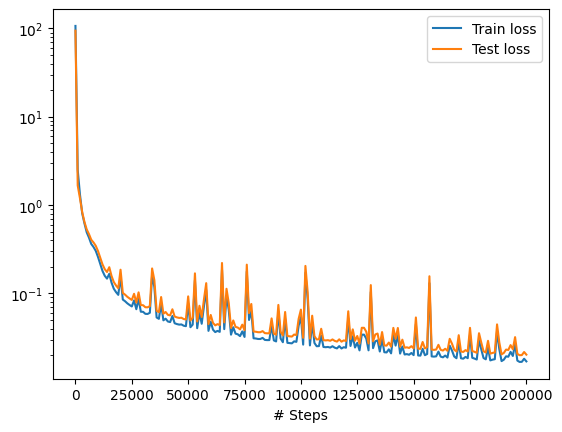

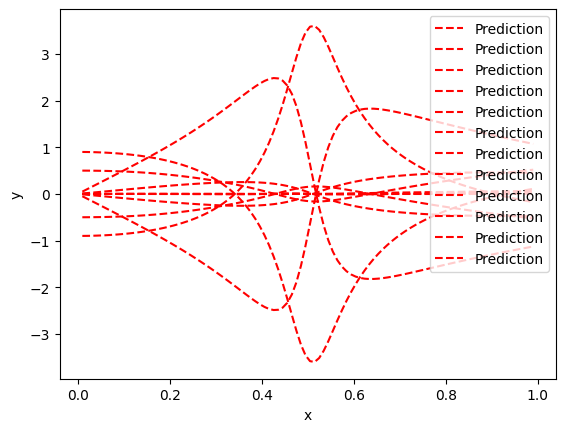

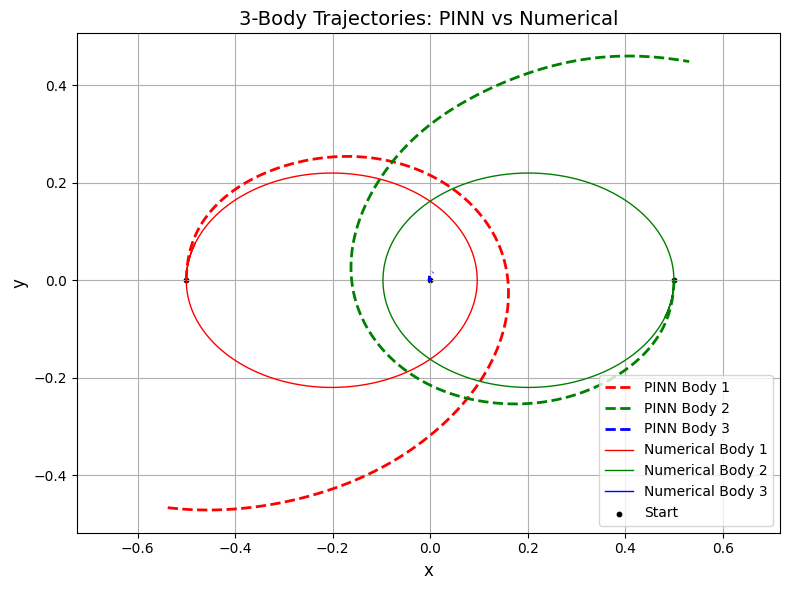


--- Relative L2 Errors (2D Position) ---
Body 1: 6.99e-01
Body 2: 6.89e-01

--- Absolute L2 Error (2D Position) ---
Body 3: 4.03e-01
(201, 12)


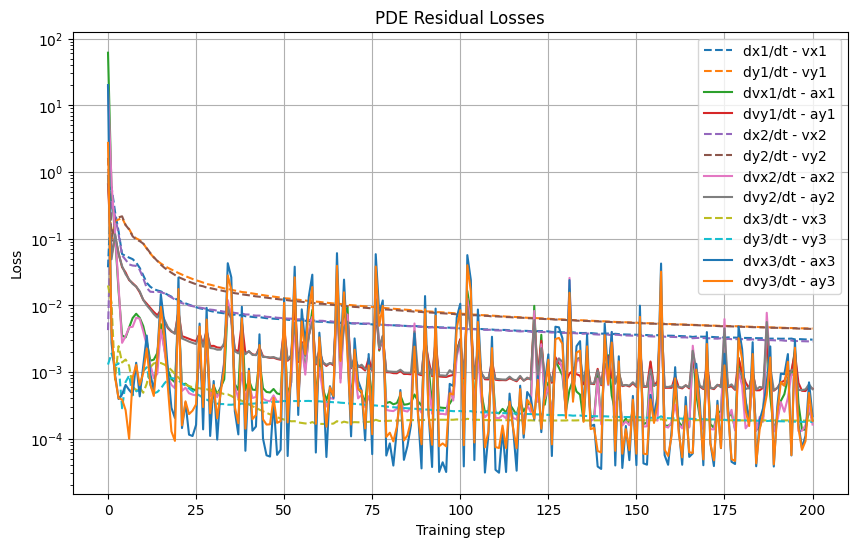

In [ ]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 4], y_pred[:, 5]
x3, y3 = y_pred[:, 8], y_pred[:, 9]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + eps)
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 + eps)
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 + eps)

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)
y0 = y0_np

sol = solve_ivp(three_body_numeric, t_span, y0, t_eval=t_eval, rtol=1e-9, atol=1e-9)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================


# Interpolate numerical solution onto PINN time grid
interp_x1 = interp1d(t_eval, x1_n, kind="cubic")
interp_y1 = interp1d(t_eval, y1_n, kind="cubic")

interp_x2 = interp1d(t_eval, x2_n, kind="cubic")
interp_y2 = interp1d(t_eval, y2_n, kind="cubic")

interp_x3 = interp1d(t_eval, x3_n, kind="cubic")
interp_y3 = interp1d(t_eval, y3_n, kind="cubic")

# Numerical reference values at PINN times
x1_ref = interp_x1(t_test[:, 0])
y1_ref = interp_y1(t_test[:, 0])

x2_ref = interp_x2(t_test[:, 0])
y2_ref = interp_y2(t_test[:, 0])

x3_ref = interp_x3(t_test[:, 0])
y3_ref = interp_y3(t_test[:, 0])

# Stack positions into vectors [x(t), y(t)]
pinn_body1 = np.vstack((x1, y1)).T
ref_body1  = np.vstack((x1_ref, y1_ref)).T

pinn_body2 = np.vstack((x2, y2)).T
ref_body2  = np.vstack((x2_ref, y2_ref)).T

pinn_body3 = np.vstack((x3, y3)).T
ref_body3  = np.vstack((x3_ref, y3_ref)).T

# Relative L2 error over full 2D trajectory
err_body1 = norm(pinn_body1 - ref_body1) / norm(ref_body1)
err_body2 = norm(pinn_body2 - ref_body2) / norm(ref_body2)
err_body3 = norm(pinn_body3 - ref_body3)    # absolute error since body 3 not moving

print("\n--- Relative L2 Errors (2D Position) ---")
print(f"Body 1: {err_body1:.2e}")
print(f"Body 2: {err_body2:.2e}")

print("\n--- Absolute L2 Error (2D Position) ---")
print(f"Body 3: {err_body3:.2e}")


# ============================================================
# History losses per pde residual
# ============================================================

losses = np.array(losshistory.loss_train)
print(losses.shape)

#dde.utils.plot_loss_history(losshistory)
residual_names = [
    "dx1/dt - vx1",
    "dy1/dt - vy1",
    "dvx1/dt - ax1",
    "dvy1/dt - ay1",

    "dx2/dt - vx2",
    "dy2/dt - vy2",
    "dvx2/dt - ax2",
    "dvy2/dt - ay2",

    "dx3/dt - vx3",
    "dy3/dt - vy3",
    "dvx3/dt - ax3",
    "dvy3/dt - ay3",
]

pde_losses = losses[:, 1:13]

plt.figure(figsize=(10, 6))

for i in range(12):
    # Position residuals style
    if i in [0, 1, 4, 5, 8, 9]:
        linestyle = "--"   # dotted/dashed for velocity terms
    else:
        linestyle = "-"    # solid  for acceleration terms

    plt.semilogy(losses[:, i], label=residual_names[i],linestyle=linestyle)

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("PDE Residual Losses")
plt.legend()
plt.grid(True)
plt.show()

